In [3]:
#importing all libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [4]:
#importing the dataset
data = pd.read_csv("titanic.csv")

In [5]:
# Loading the dataset
print("First 5 Rows:\n")
print(data.head())

print("\nColumns in Dataset:\n")
print(data.columns)

First 5 Rows:

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  

Columns in Dataset:

Index(['PassengerId', 'Survived', 'Pclass', 'Name

In [6]:
#dropping if any unnecessary columns
data = data.drop(columns=['Name', 'Ticket', 'Cabin'], errors='ignore')

In [7]:
# Fill missing Age values
if 'Age' in data.columns:
    data['Age'] = data['Age'].fillna(data['Age'].mean())


In [9]:
# Fill missing Embarked values
if 'Embarked' in data.columns:
    data['Embarked'] = data['Embarked'].fillna(
        data['Embarked'].mode()[0])

In [10]:
# Fill missing Fare values
if 'Fare' in data.columns:
    data['Fare'] = data['Fare'].fillna(data['Fare'].mean())

In [12]:
# ENCODE CATEGORICAL DATA
le = LabelEncoder()
if 'Sex' in data.columns:
    data['Sex'] = le.fit_transform(data['Sex'])
if 'Embarked' in data.columns:
    data['Embarked'] = le.fit_transform(data['Embarked'])

In [13]:
# CHECK FOR MISSING VALUES
print("\nMissing Values:\n")
print(data.isnull().sum())


Missing Values:

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


In [14]:
# CHECK TARGET COLUMN
if 'Survived' not in data.columns:
    print("\nERROR: 'Survived' column not found.")
    print("Please use Titanic TRAIN dataset, not TEST dataset.")
    exit()

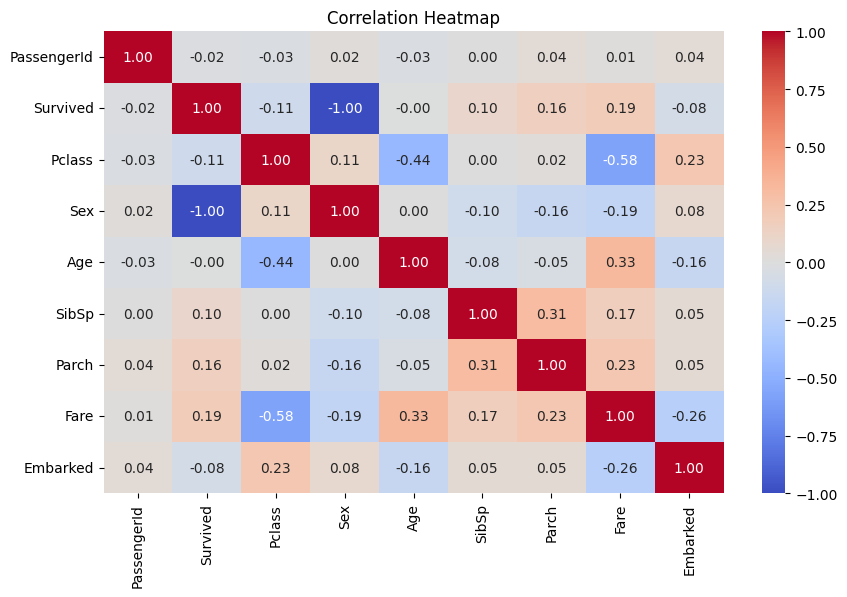

In [23]:
# CORRELATION HEATMAP
plt.figure(figsize=(10, 6))
correlation = data.corr()
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")

plt.show()

In [15]:
# FEATURES AND TARGET
X = data.drop('Survived', axis=1)
y = data['Survived']

In [16]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
# MACHINE LEARNING MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier()
}


Logistic Regression
Accuracy : 1.0
F1 Score : 1.0


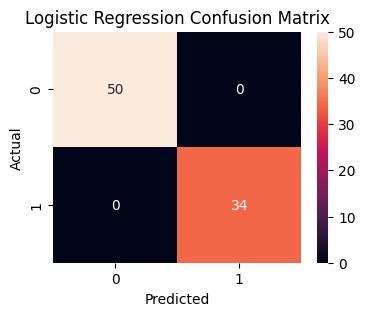


KNN
Accuracy : 0.6309523809523809
F1 Score : 0.41509433962264153


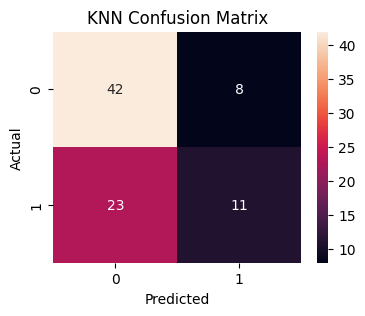


Decision Tree
Accuracy : 1.0
F1 Score : 1.0


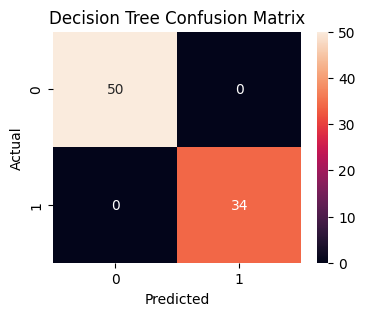

In [19]:
# TRAINING AND TESTING, PREDICTION,ACCURACY, F1 SCORE, RESULT STORING, PRINTING RESULT AND CONFUSION MATRIX
results = []
for name, model in models.items():
    print("\n=========================")
    print(name)
    print("=========================")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, accuracy, f1])
    print("Accuracy :", accuracy)
    print("F1 Score :", f1)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d'
    )
    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [20]:
# COMPARISON TABLE
result_df = pd.DataFrame(
    results,
    columns=["Algorithm", "Accuracy", "F1 Score"]
)
print("\n=========================")
print("COMPARISON TABLE")
print("=========================\n")
print(result_df)



COMPARISON TABLE

             Algorithm  Accuracy  F1 Score
0  Logistic Regression  1.000000  1.000000
1                  KNN  0.630952  0.415094
2        Decision Tree  1.000000  1.000000


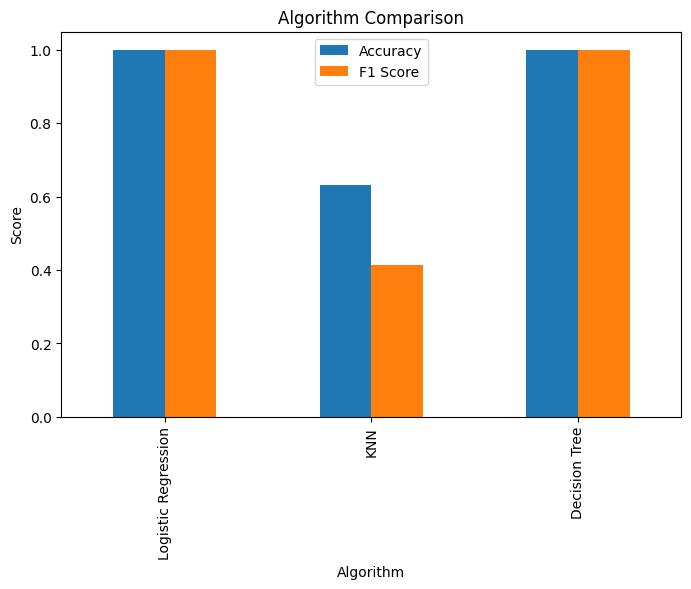

In [21]:
# BAR GRAPH
result_df.plot(
    x="Algorithm",
    y=["Accuracy", "F1 Score"],
    kind="bar",
    figsize=(8, 5)
)
plt.title("Algorithm Comparison")
plt.ylabel("Score")

plt.show()

In [22]:
# BEST MODEL
best_model = result_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print("\n=========================")
print("BEST MODEL")
print("=========================")

print(
    f"Best Algorithm: {best_model['Algorithm']}"
)
print(
    f"Best Accuracy: {best_model['Accuracy']}"
)


BEST MODEL
Best Algorithm: Logistic Regression
Best Accuracy: 1.0
